In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
import random

all_tweets = pd.read_csv("tweets.csv")
df = pd.read_csv("dei_tweets_merged.csv")

In [ ]:
# --------- 10 random DEI tweets --------- #
sample = df.sample(10, random_state=42)

for i, row in sample.iterrows():
    print(f"--- Tweet {i} ---")
    print(f"Year: {row['year']}")
    print(f"CEO: {row['CEO']}")
    print(f"Company: {row['company']}")
    print(f"Tweet:\n{row['text']}")
    print("\n")

In [ ]:
# --------- Incomplete DEI tweets --------- #
dots_count = df["text"].str.endswith(("…")).sum()
print(f"Number of tweets ending with '…': {dots_count}")

In [ ]:
# --------- Overview of DEI tweets --------- #

df["id"] = df["id"].astype(str)
df["year"] = pd.to_datetime(df["created_at"], errors="coerce").dt.year

# Tweets per year
year_counts = (
    df.groupby("year")["id"]
    .count()
    .reset_index()
    .rename(columns={"id": "tweet_count"})
    .sort_values("year")
)

print("\nTweets published per year:\n")
print(year_counts.to_string(index=False))

# Tweets per CEO (+ Company)
ceo_overview = (
    df.dropna(subset=["CEO"])
    .groupby(["CEO", "company"])["id"]
    .count()
    .reset_index()
    .rename(columns={"id": "tweet_count"})
    .sort_values("tweet_count", ascending=False)
)

print("\nTweets published per CEO:\n")
print(ceo_overview.to_string(index=False))

In [ ]:
# ---------------- 1. Time series of tweets per year ---------------- #
tweets_per_year = df.groupby("year").size()

plt.figure(figsize=(10, 5), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")
tweets_per_year.plot(kind="line", marker="o", ax=ax)
plt.title("Number of DEI Tweets Published per Year")
plt.xlabel("Year")
plt.ylabel("Number of Tweets")
plt.grid(True)
plt.xticks(tweets_per_year.index)
plt.tight_layout()
plt.show()

# ---------------- 2. Time series of tweets per year (percentage) ---------------- #
tweets_per_year_total = all_tweets.groupby("year").size()
dei_per_year = df.groupby("year").size()
dei_percentage = (dei_per_year / tweets_per_year_total * 100).fillna(0)

plt.figure(figsize=(10, 5), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

dei_percentage.plot(kind="line", marker="o", ax=ax)
plt.title("Percentage of DEI Tweets Published per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Tweets (%)")
plt.grid(True)
plt.xticks(dei_percentage.index)
plt.tight_layout()
plt.show()

# ---------------- 3. Top 10 CEOs by number of tweets ---------------- #
ceo_counts = df.groupby(["CEO", "company"]).size().reset_index(name="tweet_count")
top_ceos = ceo_counts.sort_values("tweet_count", ascending=False).head(10)

plt.figure(figsize=(12, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

plt.barh(top_ceos["CEO"] + " (" + top_ceos["company"] + ")", top_ceos["tweet_count"])
plt.xlabel("Number of Tweets")
plt.title("Top 10 CEOs by Number of DEI Tweets Published")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---------------- 4. Top 10 CEOs by number of tweets (percentage) ---------------- #
total_ceo_counts = all_tweets.groupby(["CEO", "company"]).size().reset_index(name="total_tweets")
dei_ceo_counts = df.groupby(["CEO", "company"]).size().reset_index(name="dei_tweets")
merged = pd.merge(dei_ceo_counts, total_ceo_counts, on=["CEO", "company"], how="left")
merged["percentage"] = (merged["dei_tweets"] / merged["total_tweets"]) * 100
filtered = merged[merged["dei_tweets"] >= 20]
top10 = filtered.sort_values("percentage", ascending=False).head(10)

plt.figure(figsize=(12, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")
bars = ax.barh(top10["CEO"] + " (" + top10["company"] + ")", top10["percentage"])
ax.invert_yaxis()
for bar, count in zip(bars, top10["dei_tweets"]):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va="center", ha="left", fontsize=10)

plt.xlabel("Percentage of DEI Tweets (%)")
plt.title("Top 10 CEOs by Percentage of DEI Tweets (≥20 DEI tweets)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Promotion vs. Prevention

In [ ]:
# ---------------- Method 1: Classification Labels ---------------- #
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
labels = [
    "Message emphasising growth, opportunity, innovation, progress, empowerment",
    "Message emphasising risk avoidance, safety, compliance, obligation, regulation"
]
label_map = {
    labels[0]: "Promotion",
    labels[1]: "Prevention"
}

# Classify each tweet
def classify_tweet(text):
    result = classifier(text, candidate_labels=labels, multi_label=False)
    long_label = result["labels"][0]
    return label_map[long_label]

df["DEI_focus"] = df["text"].apply(classify_tweet)

print(df[["text", "DEI_focus"]].head(10))
print(df["DEI_focus"].value_counts())

In [9]:
# ---------------- Method 2: Classification NLI ---------------- #
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="roberta-large-mnli"
)

labels = ["Promotion", "Prevention"]

hypotheses = {
    "Promotion": "This tweet expresses promotion-focused framing such as growth, opportunity, empowerment, or innovation.",
    "Prevention": "This tweet expresses prevention-focused framing such as risk avoidance, compliance, obligation, or regulation."
}


def classify_tweet_nli(text):
    result = classifier(
        text,
        candidate_labels=list(hypotheses.keys()),
        hypothesis_template="The message is {}."
    )
    return result["labels"][0]   # top prediction

df["DEI_focus"] = df["text"].apply(classify_tweet_nli)


Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


In [10]:
# Count how many tweets were classified into each category
promotion_count = (df["DEI_focus"] == "Promotion").sum()
prevention_count = (df["DEI_focus"] == "Prevention").sum()

print("Promotion-focused tweets:", promotion_count)
print("Prevention-focused tweets:", prevention_count)
print("Total classified:", promotion_count + prevention_count)


Promotion-focused tweets: 1477
Prevention-focused tweets: 549
Total classified: 2026


In [18]:
# ---------------- 20 random tweets ---------------- #
promotion_tweets = df[df["DEI_focus"] == "Promotion"]
prevention_tweets = df[df["DEI_focus"] == "Prevention"]

print("\n--- 10 Random Promotion-Focused Tweets ---\n")
for _, row in promotion_tweets.sample(min(10, len(promotion_tweets)), random_state=42).iterrows():
    print(f"Year: {row.get('year', 'N/A')}, Author: {row.get('CEO', row.get('author_id', 'N/A'))}, Company: {row.get('company', 'N/A')}")
    print(row['text'])
    print("-"*80)

print("\n--- 10 Random Prevention-Focused Tweets ---\n")
for _, row in prevention_tweets.sample(min(10, len(prevention_tweets)), random_state=42).iterrows():
    print(f"Year: {row.get('year', 'N/A')}, Author: {row.get('CEO', row.get('author_id', 'N/A'))}, Company: {row.get('company', 'N/A')}")
    print(row['text'])
    print("-"*80)


--- 10 Random Promotion-Focused Tweets ---

Year: 2019, Author: Marc Benioff, Company: Salesforce
RT @Dreamforce: Marc @Benioff's New Book Talks About Bringing Your Values to Work and Being a #PlatformForChange 

Check out more about #Tr…
--------------------------------------------------------------------------------
Year: 2019, Author: Michael J. Farrell, Company: ResMed
RT @ResMed: Thanks @WomensForumNY for recognizing 300+ leading companies with +30% female representation on their corporate boards. We’re p…
--------------------------------------------------------------------------------
Year: 2018, Author: Sundar Pichai, Company: Alphabet Inc. (Class A)
On this #InternationalWomensDay and every day, we stand together to celebrate and support women everywhere
--------------------------------------------------------------------------------
Year: 2019, Author: Andy Jassy, Company: Amazon
Happy to see the CA legislation on banning private prisons. It's nuts that the US has 5% of the w

In [ ]:
# ---------------- Check for accuracy of classification ---------------- #
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import mutual_info_score
import numpy as np

def compute_mutual_information(texts, labels):
    # Convert labels to integers
    label_ids = np.array([0 if l == "Prevention" else 1 for l in labels])
    # Convert text into bag-of-words matrix
    vectorizer = CountVectorizer(
        max_features=5000,   # cap vocab to avoid overfitting
        stop_words='english'
    )
    X = vectorizer.fit_transform(texts)
    # Compute MI for each feature with the label
    mi_scores = []
    for i in range(X.shape[1]):
        feature_column = X[:, i].toarray().ravel()
        mi = mutual_info_score(feature_column, label_ids)
        mi_scores.append(mi)
    # Overall MI = mean MI across all word features
    overall_mi = np.mean(mi_scores)
    # Sort top informative words
    vocab = np.array(vectorizer.get_feature_names_out())
    top_indices = np.argsort(mi_scores)[::-1][:20]
    top_words = [(vocab[i], mi_scores[i]) for i in top_indices]
    return overall_mi, top_words

tweets_list = df["text"].tolist()
labels_list = df["DEI_focus"].tolist()
overall_mi, top_words = compute_mutual_information(tweets_list, labels_list)

print("Overall MI:", overall_mi)
print("Top informative words:")
for word, score in top_words:
    print(f"{word}: {score:.4f}")

In [ ]:
# ---------------- Count tweets whose text ends with "..." ----------------
import pandas as pd

# Load the CSV file
df = pd.read_csv("dei_tweets_merged.csv")

count_ellipsis = df["text"].astype(str).str.endswith("…").sum()

# Total number of tweets
total_tweets = len(df)

# Percentage
percentage = (count_ellipsis / total_tweets) * 100

print("Number of tweets ending with '…':", count_ellipsis)
print(f"Percentage: {percentage:.2f}%")



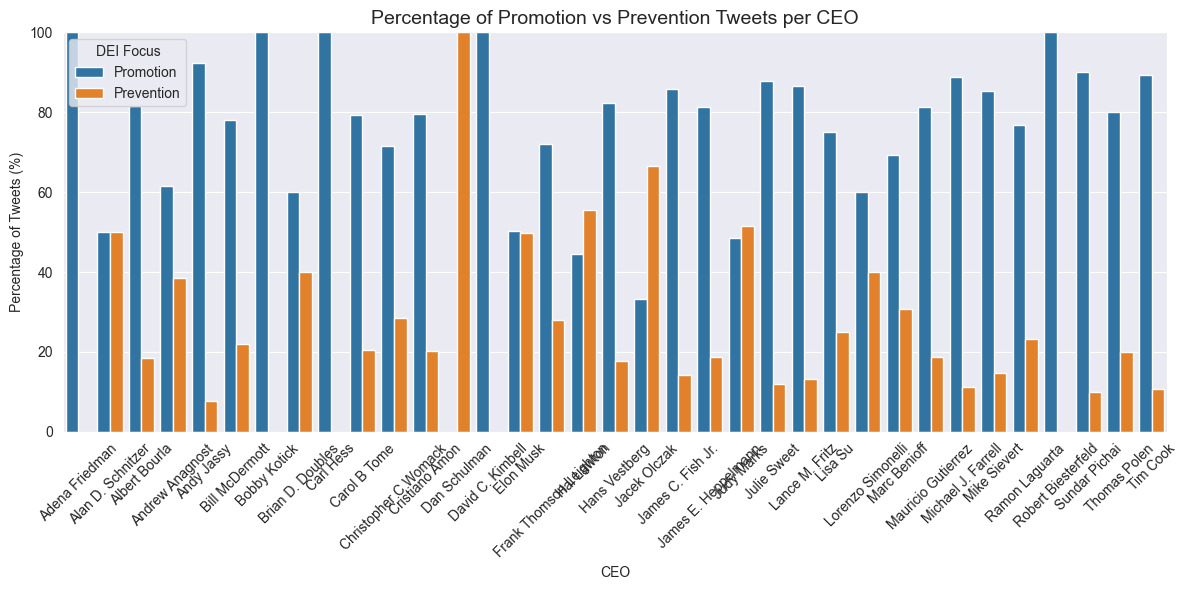

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df already has columns: 'CEO', 'DEI_focus'

# Count tweets per CEO and DEI_focus category
counts = df.groupby(["CEO", "DEI_focus"]).size().reset_index(name="count")

# Compute total tweets per CEO
totals = counts.groupby("CEO")["count"].transform("sum")

# Calculate percentage
counts["percentage"] = counts["count"] / totals * 100

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=counts, x="CEO", y="percentage", hue="DEI_focus")

plt.title("Percentage of Promotion vs Prevention Tweets per CEO", fontsize=14)
plt.xlabel("CEO")
plt.ylabel("Percentage of Tweets (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend(title="DEI Focus")
plt.tight_layout()
plt.show()


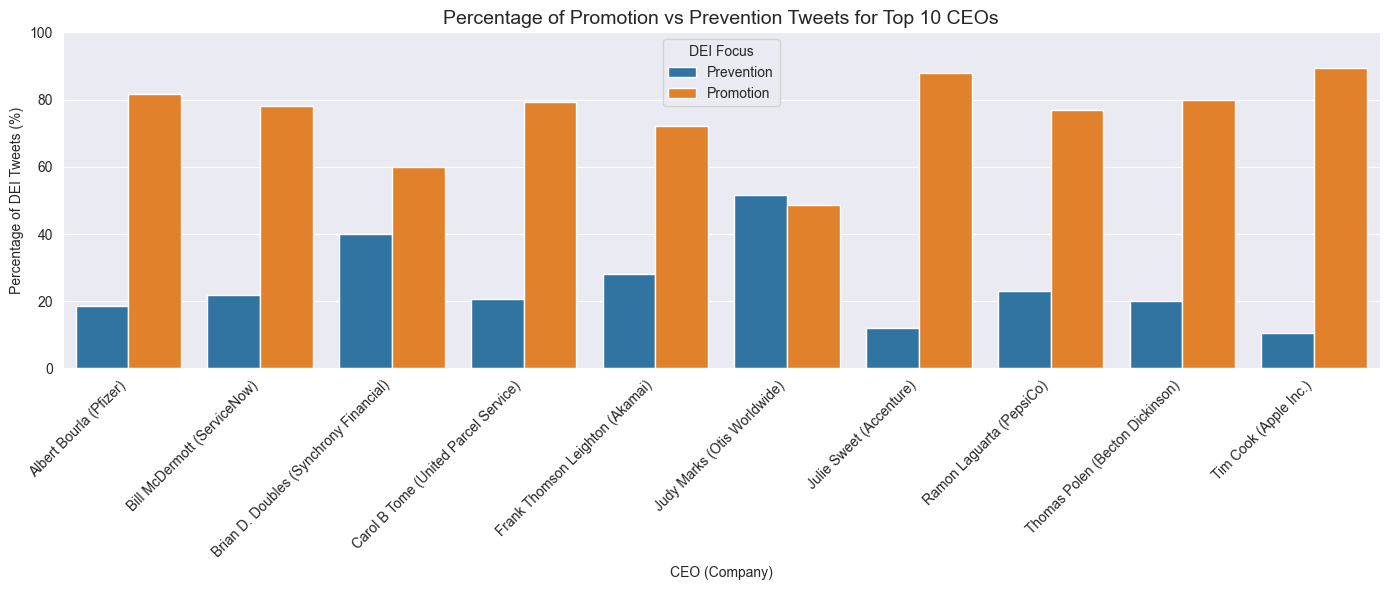

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df has columns 'CEO', 'company', 'DEI_focus'
# all_tweets is the full dataset (including non-DEI tweets)

# Step 1: Compute total tweets per CEO
total_ceo_counts = all_tweets.groupby(["CEO", "company"]).size().reset_index(name="total_tweets")

# Step 2: Compute DEI tweets per CEO
dei_ceo_counts = df.groupby(["CEO", "company"]).size().reset_index(name="dei_tweets")

# Step 3: Merge and compute percentage
merged = pd.merge(dei_ceo_counts, total_ceo_counts, on=["CEO", "company"], how="left")
merged["percentage"] = (merged["dei_tweets"] / merged["total_tweets"]) * 100

# Step 4: Filter CEOs with at least 20 DEI tweets
filtered = merged[merged["dei_tweets"] >= 20]

# Step 5: Select top 10 CEOs by percentage
top10_ceos = filtered.sort_values("percentage", ascending=False).head(10)

# Step 6: Prepare data for plotting only for top 10 CEOs
plot_data = df[df["CEO"].isin(top10_ceos["CEO"])].copy()

# Create new x-axis label with CEO and company
ceo_company_map = dict(zip(top10_ceos["CEO"], top10_ceos["company"]))
plot_data["CEO_label"] = plot_data["CEO"].apply(lambda x: f"{x} ({ceo_company_map[x]})")

# Count Promotion/Prevention per CEO_label
counts = plot_data.groupby(["CEO_label", "DEI_focus"]).size().reset_index(name="count")

# Compute percentage per CEO_label
totals = counts.groupby("CEO_label")["count"].transform("sum")
counts["percentage"] = counts["count"] / totals * 100

# Step 7: Plot
plt.figure(figsize=(14, 6))
sns.barplot(data=counts, x="CEO_label", y="percentage", hue="DEI_focus")

plt.title("Percentage of Promotion vs Prevention Tweets for Top 10 CEOs", fontsize=14)
plt.xlabel("CEO (Company)")
plt.ylabel("Percentage of DEI Tweets (%)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend(title="DEI Focus")
plt.tight_layout()
plt.show()


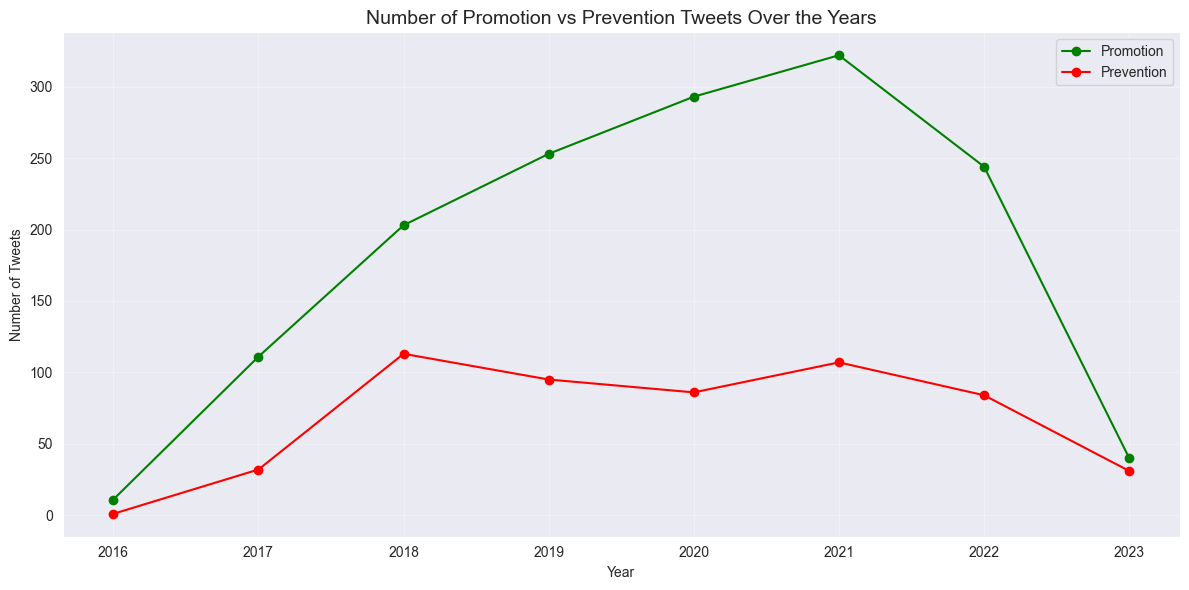

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Count tweets per year and DEI_focus
time_series = df.groupby(['year', 'DEI_focus']).size().reset_index(name='count')

# Pivot for easier plotting
ts_pivot = time_series.pivot(index='year', columns='DEI_focus', values='count').fillna(0)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(ts_pivot.index, ts_pivot['Promotion'], marker='o', label='Promotion', color='green')
plt.plot(ts_pivot.index, ts_pivot['Prevention'], marker='o', label='Prevention', color='red')

plt.title("Number of Promotion vs Prevention Tweets Over the Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Tweets")
plt.xticks(ts_pivot.index)  # show all years
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
